In [3]:
!pip install beautifulsoup4

In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
sns.set(style="whitegrid")

In [55]:
base_url = "https://webscraper.io"

In [63]:
categories = {
    "laptops": "/test-sites/e-commerce/static/computers/laptops",
    "tablets": "/test-sites/e-commerce/static/computers/tablets",
    "phones": "/test-sites/e-commerce/static/phones/touch"
}

In [64]:
data = []

for category_name, category_path in categories.items():

    print("Scraping category:", category_name)

    for page in range(1,6):  # kita coba 5 halaman

        url = base_url + category_path + "?page=" + str(page)

        print("Page:", page)

        response = requests.get(url)

        soup = BeautifulSoup(response.text,"html.parser")

        products = soup.find_all("div", class_="thumbnail")

        if len(products) == 0:
            break

        for product in products:

            name = product.find("a", class_="title").text.strip()
            price = product.find("h4", class_="price").text.strip()
            description = product.find("p", class_="description").text.strip()

            review_tag = product.find("p", class_="pull-right")

            if review_tag:
                reviews = review_tag.text.strip()
            else:
                reviews = "0 reviews"

            data.append({
                "product_name": name,
                "price": price,
                "description": description,
                "reviews": reviews,
                "category": category_name
            })

Scraping category: laptops
Page: 1
Page: 2
Page: 3
Page: 4
Page: 5
Scraping category: tablets
Page: 1
Page: 2
Page: 3
Page: 4
Page: 5
Scraping category: phones
Page: 1
Page: 2
Page: 3


In [65]:
df = pd.DataFrame(data)

In [66]:
df.shape

(60, 5)

In [67]:
df["price"] = df["price"].str.replace("$","")
df["price"] = df["price"].astype(float)

In [68]:
df["reviews"] = df["reviews"].astype(str)
df["reviews"] = df["reviews"].str.extract(r"(\d+)")
df["reviews"] = df["reviews"].astype(int)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  60 non-null     object 
 1   price         60 non-null     float64
 2   description   60 non-null     object 
 3   reviews       60 non-null     int64  
 4   category      60 non-null     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 2.5+ KB


In [70]:
df.isnull().sum()

,0
product_name,0
price,0
description,0
reviews,0
category,0


In [71]:
df["category"].value_counts()

,count
category,
laptops,30
tablets,21
phones,9


In [72]:
df.to_csv("ecommerce_products_full.csv", index=False)

In [73]:
df.head()

,product_name,price,description,reviews,category
0,Packard 255 G2,416.99,"15.6"", AMD E2-3800 1.3GHz, 4GB, 500GB, Windows...",0,laptops
1,Aspire E1-510,306.99,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux",0,laptops
2,ThinkPad T540p,1178.99,"15.6"", Core i5-4200M, 4GB, 500GB, Win7 Pro 64bit",0,laptops
3,ProBook,739.99,"14"", Core i5 2.6GHz, 4GB, 500GB, Win7 Pro 64bit",0,laptops
4,ThinkPad X240,1311.99,"12.5"", Core i5-4300U, 8GB, 240GB SSD, Win7 Pro...",0,laptops


In [74]:
df["price"].describe()

,price
count,60.000000
mean,591.371833
std,473.309114
min,24.990000
25%,128.740000
50%,529.490000
75%,899.247500
max,1799.000000


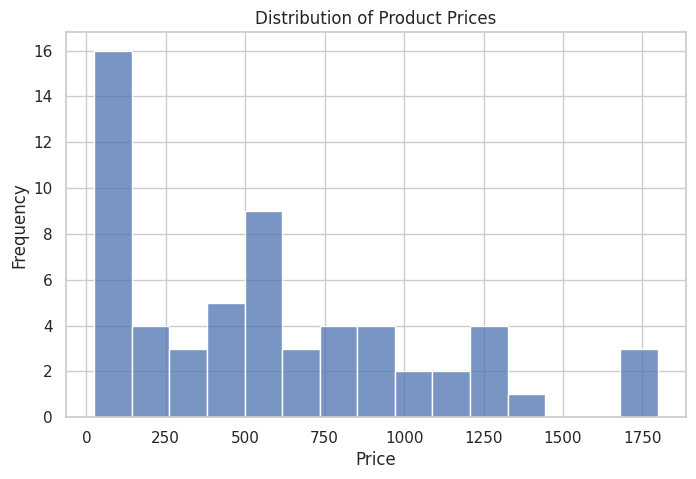

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=15)

plt.title("Distribution of Product Prices")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

In [76]:
df.groupby("category")["price"].mean()

,price
category,
laptops,900.120333
phones,400.656667
tablets,232.037619


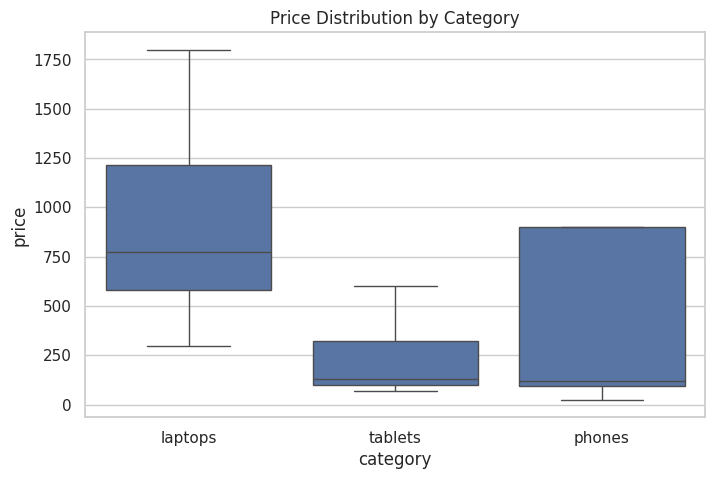

In [77]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="category", y="price")

plt.title("Price Distribution by Category")

plt.show()

In [78]:
df.sort_values("price", ascending=False).head(10)

,product_name,price,description,reviews,category
28,Asus ROG Strix...,1799.00,"Asus ROG Strix SCAR Edition GL503VM-ED115T, 15...",0,laptops
26,Asus ROG Strix...,1769.00,"Asus ROG Strix GL702ZC-GC154T, 17.3"" FHD, Ryze...",0,laptops
27,Asus ROG Strix...,1769.00,"Asus ROG Strix GL702ZC-GC209T, 17.3"" FHD IPS, ...",0,laptops
25,Lenovo Legion...,1399.00,"Lenovo Legion Y720, 15.6"" FHD IPS, Core i7-770...",0,laptops
4,ThinkPad X240,1311.99,"12.5"", Core i5-4300U, 8GB, 240GB SSD, Win7 Pro...",0,laptops
9,Dell XPS 13,1281.99,"13.3"" Touch, Core i5-4210U, 8GB, 128GB SSD, Wi...",0,laptops
10,ThinkPad X230,1244.99,"12.5"", Core i5 2.6GHz, 8GB, 180GB SSD, Win7 Pr...",0,laptops
12,ThinkPad Yoga,1223.99,"12.5"" Touch, Core i5 4200U, 8GB, 500GB + 16GB ...",0,laptops
2,ThinkPad T540p,1178.99,"15.6"", Core i5-4200M, 4GB, 500GB, Win7 Pro 64bit",0,laptops
24,Lenovo Legion...,1149.00,"Lenovo Legion Y520-15IKBM, 15.6"" FHD IPS, Core...",0,laptops


In [79]:
df.sort_values("reviews", ascending=False).head(10)

,product_name,price,description,reviews,category
0,Packard 255 G2,416.99,"15.6"", AMD E2-3800 1.3GHz, 4GB, 500GB, Windows...",0,laptops
1,Aspire E1-510,306.99,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux",0,laptops
2,ThinkPad T540p,1178.99,"15.6"", Core i5-4200M, 4GB, 500GB, Win7 Pro 64bit",0,laptops
3,ProBook,739.99,"14"", Core i5 2.6GHz, 4GB, 500GB, Win7 Pro 64bit",0,laptops
4,ThinkPad X240,1311.99,"12.5"", Core i5-4300U, 8GB, 240GB SSD, Win7 Pro...",0,laptops
5,Aspire E1-572G,581.99,"15.6"", Core i5-4200U, 8GB, 1TB, Radeon R7 M265...",0,laptops
6,ThinkPad Yoga,1033.99,"12.5"" Touch, Core i3-4010U, 4GB, 500GB + 16GB ...",0,laptops
7,Pavilion,609.99,"15.6"", Core i5-4200U, 6GB, 750GB, Windows 8.1",0,laptops
8,Inspiron 15,745.99,"Moon Silver, 15.6"", Core i7-4510U, 8GB, 1TB, R...",0,laptops
9,Dell XPS 13,1281.99,"13.3"" Touch, Core i5-4210U, 8GB, 128GB SSD, Wi...",0,laptops


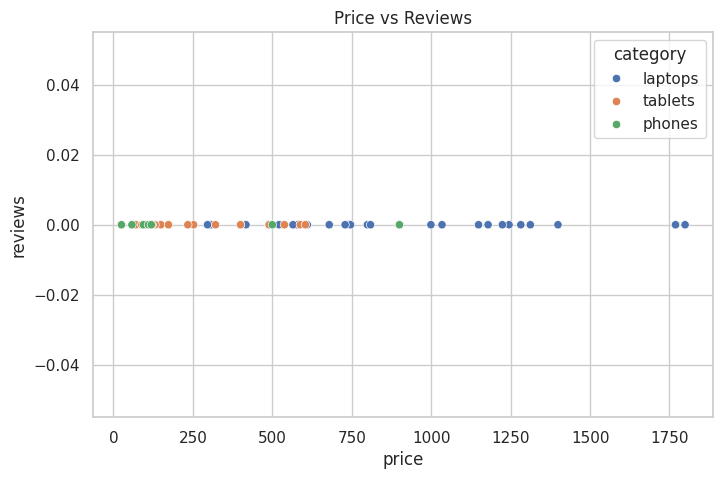

In [80]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="price", y="reviews", hue="category")

plt.title("Price vs Reviews")

plt.show()

In [81]:
df.to_csv("ecommerce_products_clean.csv", index=False)